# LIMPIEZA DE DATOS

In [12]:
## IMPORTS
import os

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = '/content/drive/MyDrive/TFM_NoeliaGarciaGarcia/Pipeline'
else:
    BASE_PATH = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(f"Entorno: {'Colab' if IN_COLAB else 'Local'}")
print(f"BASE_PATH: {BASE_PATH}")

Entorno: Local
BASE_PATH: g:\Mi unidad\TFM_NoeliaGarciaGarcia\Pipeline


# CARGA DE DATOS

In [13]:
df_flux = pd.read_csv(os.path.join(BASE_PATH, "DATA", "CLEAN", "df_flux_clean.csv"), sep=r",")
qc = pd.read_csv(os.path.join(BASE_PATH, "DATA", "CLEAN", "qc.csv"), sep=r",")

print(f"df_flux: {df_flux.shape}")
print(f"qc: {qc.shape}")

df_flux: (660, 19)
qc: (690, 11)


In [14]:
# Lectura de parámetros desde config.xlsx
config = pd.read_excel(os.path.join(BASE_PATH, "NOTEBOOKS", "config.xlsx"), sheet_name="config", index_col="parameter")["value"]
fs = int(config["fs"])
window_minutes = int(config["window_minutes"])
samples_per_window = fs * 60 * window_minutes

print(f"fs={fs}, window_minutes={window_minutes}, samples_per_window={samples_per_window}")

fs=8, window_minutes=15, samples_per_window=7200


# DETECCIÓN DE OUTLIERS GLOBALES

Se detectan outliers en las variables agregadas por ventana usando el método Hampel (basado en MAD). Las ventanas con outliers se marcan con un flag sin eliminar ni modificar los datos.

In [15]:
cols_limpieza_global = [
    "flux_O2",
    "mean_O2",
    "mean_vz"
]

cols_limpieza_global = [
    c for c in cols_limpieza_global
    if c in df_flux.columns
]

In [16]:
def detectar_outliers_hampel_global(df, cols, factor=3):
    df_out = df.copy()
    resumen = []

    for col in cols:
        serie = df_out[col]

        mediana = serie.median()
        mad = np.median(np.abs(serie - mediana))

        if mad == 0 or np.isnan(mad):
            df_out[f"{col}_outlier_global"] = False
            continue

        umbral = factor * 1.4826 * mad
        mascara = np.abs(serie - mediana) > umbral

        df_out[f"{col}_outlier_global"] = mascara

        resumen.append({
            "variable": col,
            "mediana": mediana,
            "mad": mad,
            "umbral": umbral,
            "n_outliers": mascara.sum(),
            "pct_outliers": 100 * mascara.mean()
        })

    return df_out, pd.DataFrame(resumen)

In [17]:
df_global_diag, resumen_global = detectar_outliers_hampel_global(
    df_flux,
    cols=cols_limpieza_global,
    factor=3
)

display(resumen_global)

,variable,mediana,mad,umbral,n_outliers,pct_outliers
0,flux_O2,-7.464560,3.979172,17.698560,88,13.333333
1,mean_O2,221.368747,3.826812,17.020895,42,6.363636
2,mean_vz,-0.001339,0.000710,0.003159,24,3.636364


In [18]:
# Flag outlier global: True si es outlier en CUALQUIER variable agregada
cols_outlier = [c for c in df_global_diag.columns if c.endswith("_outlier_global")]
df_global_diag["flag_outlier_global"] = df_global_diag[cols_outlier].any(axis=1)

# Flag outlier ventana: True si la ventana tenía outliers en las muestras crudas (viene de qc.csv)
if "has_outliers" in qc.columns and "window_id" in qc.columns:
    qc_outliers = qc[["window_id", "has_outliers"]].copy()
    qc_outliers["has_outliers"] = qc_outliers["has_outliers"].astype(bool)
    df_global_diag = df_global_diag.merge(qc_outliers, on="window_id", how="left")
    df_global_diag["flag_outlier_window"] = df_global_diag["has_outliers"].fillna(False).astype(bool)
    df_global_diag.drop(columns=["has_outliers"], inplace=True)
else:
    df_global_diag["flag_outlier_window"] = False
    print("⚠ Columna 'has_outliers' no encontrada en qc.csv")

n_global = df_global_diag["flag_outlier_global"].sum()
n_window = df_global_diag["flag_outlier_window"].sum()
n_total = len(df_global_diag)
print(f"flag_outlier_global:  {n_global} ({100*n_global/n_total:.1f}%) — outliers en variables agregadas")
print(f"flag_outlier_window:  {n_window} ({100*n_window/n_total:.1f}%) — ventanas con outliers en señal cruda")

# Eliminar columnas auxiliares por variable
df_flux_clean_global = df_global_diag.drop(columns=cols_outlier)
df_flux_clean_global.head()

flag_outlier_global:  136 (20.6%) — outliers en variables agregadas
flag_outlier_window:  322 (48.8%) — ventanas con outliers en señal cruda


,window_id,hour,day,flux_O2,accumulated_flux_O2,optimal_shift_samples,optimal_shift_sec,optimal_shift_day,mean_vx,mean_vy,...,mean_speed,mean_O2,mean_temp,valid_flux_window,flux_status,mean_pres,std_pres,flux_smooth,flag_outlier_global,flag_outlier_window
0,0,13.125009,0.546875,-9.869224,-0.102804,-8.0,-1.000,-0.000012,-1.714890,3.480262,...,4.071525,219.341074,14.859783,True,ok,1482.007222,4.667272,-6.351335,False,False
1,1,13.375009,0.557292,-12.440802,-0.129592,-7.0,-0.875,-0.000010,-1.702691,4.693565,...,5.161068,220.214211,14.832664,True,ok,1496.564576,5.315008,-6.745481,False,False
2,2,13.625009,0.567709,-6.206313,-0.064649,-8.0,-1.000,-0.000012,-1.457192,4.596101,...,4.948867,220.537457,14.821121,True,ok,1513.696097,5.783879,-6.619435,False,False
3,3,13.875009,0.578125,-3.094532,-0.032235,15.0,1.875,0.000022,-0.720594,4.239672,...,4.422528,220.398051,14.816509,True,ok,1531.393618,5.371816,-6.799723,False,False
4,4,14.125009,0.588542,-10.561338,-0.110014,-7.0,-0.875,-0.000010,-0.909696,3.509688,...,3.791829,220.429227,14.806283,True,ok,1550.554493,5.584106,-6.911006,False,False


# FLAGS DE CALIDAD

Se marcan ventanas sospechosas sin eliminar ni modificar datos:
- **`flag_outlier_global`**: la ventana tiene al menos un valor outlier (Hampel/MAD) en alguna de las variables agregadas (flux_O2, mean_O2, mean_vz).
- **`flag_outlier_window`**: la ventana contenía muestras individuales atípicas en la señal cruda (O2/vz a 8 Hz), detectadas en NB1.
- **`flag_flux_positivo`**: el flujo acumulado de O2 es positivo (producción neta), inusual en sedimentos marinos.
- **`flag_vel_baja`**: el módulo medio de la velocidad (sqrt(vx²+vy²+vz²)) es muy bajo, posible sensor atascado o sin flujo real.

In [19]:
# Flags de calidad (no eliminan datos, solo marcan)
df_flux_clean_global["flag_flux_positivo"] = df_flux_clean_global["accumulated_flux_O2"] > 0
df_flux_clean_global["flag_vel_baja"] = df_flux_clean_global["mean_speed"] < 0.005  # Módulo medio de velocidad xyz muy bajo

# Resumen
n_total = len(df_flux_clean_global)
n_flux_pos = df_flux_clean_global["flag_flux_positivo"].sum()
n_vel_baja = df_flux_clean_global["flag_vel_baja"].sum()
n_ambos = (df_flux_clean_global["flag_flux_positivo"] & df_flux_clean_global["flag_vel_baja"]).sum()

print(f"Total ventanas: {n_total}")
print(f"  flag_flux_positivo: {n_flux_pos} ({100*n_flux_pos/n_total:.1f}%)")
print(f"  flag_vel_baja:      {n_vel_baja} ({100*n_vel_baja/n_total:.1f}%)")
print(f"  ambos flags:        {n_ambos} ({100*n_ambos/n_total:.1f}%)")

Total ventanas: 660
  flag_flux_positivo: 92 (13.9%)
  flag_vel_baja:      0 (0.0%)
  ambos flags:        0 (0.0%)


# VISUALIZACIÓN

Puntos en naranja = ventanas con al menos un flag activo (outlier, flujo positivo o velocidad baja).

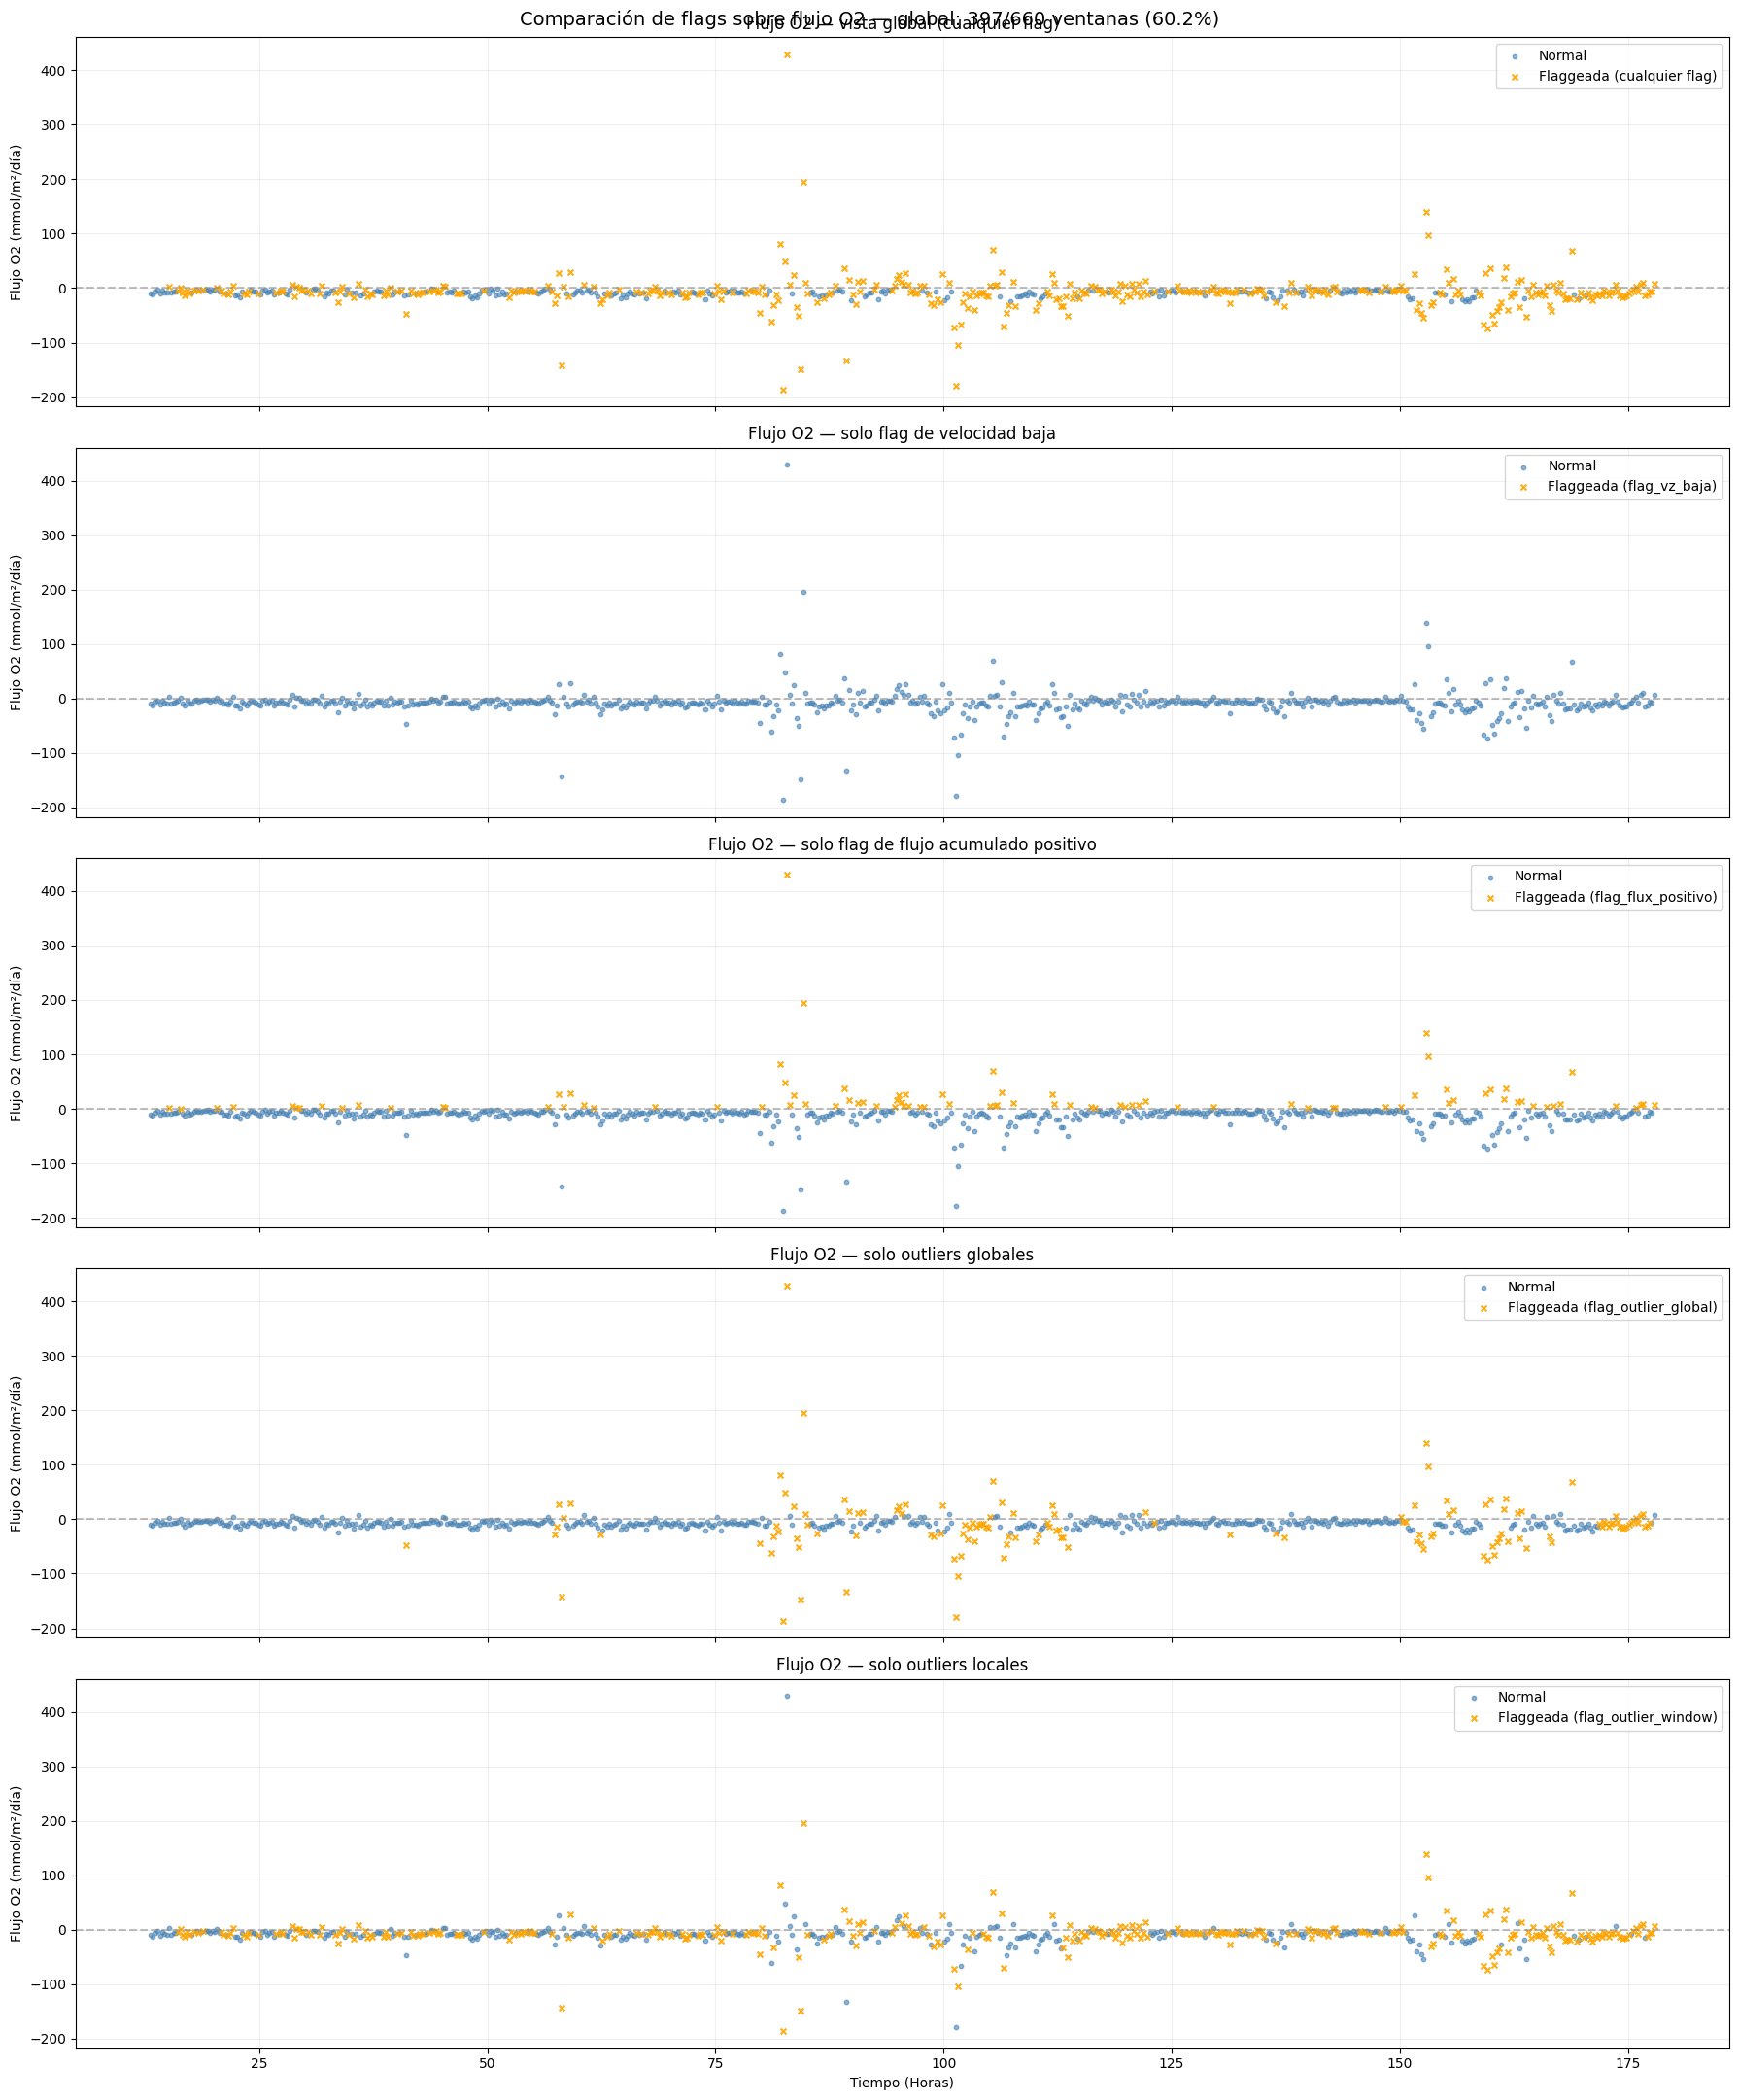

In [20]:
# Flags individuales
flag_global = df_flux_clean_global["flag_outlier_global"]
flag_local = df_flux_clean_global["flag_outlier_window"]
flag_flux_pos = df_flux_clean_global["flag_flux_positivo"]
flag_vz_baja = df_flux_clean_global["flag_vel_baja"]

# Flag combinado (global)
any_flag = flag_global | flag_local | flag_flux_pos | flag_vz_baja

fig, axes = plt.subplots(5, 1, figsize=(18, 22), sharex=True)


def plot_flujo_por_flag(ax, mask_flag, titulo, etiqueta_flag):
    ax.scatter(
        df_flux_clean_global.loc[~mask_flag, "hour"],
        df_flux_clean_global.loc[~mask_flag, "flux_O2"],
        alpha=0.6, s=10, label="Normal", color="steelblue"
    )
    ax.scatter(
        df_flux_clean_global.loc[mask_flag, "hour"],
        df_flux_clean_global.loc[mask_flag, "flux_O2"],
        alpha=0.9, s=18, label=etiqueta_flag, color="orange", marker="x"
    )
    ax.axhline(0, linestyle="--", alpha=0.5, color="gray")
    ax.set_ylabel("Flujo O2 (mmol/m²/día)")
    ax.set_title(titulo)
    ax.grid(True, alpha=0.2)
    ax.legend()


# 1) Global: cualquier flag
plot_flujo_por_flag(
    axes[0],
    any_flag,
    "Flujo O2 — vista global (cualquier flag)",
    "Flaggeada (cualquier flag)"
)

# 2) Solo velocidad baja
plot_flujo_por_flag(
    axes[1],
    flag_vz_baja,
    "Flujo O2 — solo flag de velocidad baja",
    "Flaggeada (flag_vz_baja)"
)

# 3) Solo flujo acumulado positivo
plot_flujo_por_flag(
    axes[2],
    flag_flux_pos,
    "Flujo O2 — solo flag de flujo acumulado positivo",
    "Flaggeada (flag_flux_positivo)"
)

# 4) Solo outliers globales
plot_flujo_por_flag(
    axes[3],
    flag_global,
    "Flujo O2 — solo outliers globales",
    "Flaggeada (flag_outlier_global)"
)

# 5) Solo outliers locales (ventana)
plot_flujo_por_flag(
    axes[4],
    flag_local,
    "Flujo O2 — solo outliers locales",
    "Flaggeada (flag_outlier_window)"
)

axes[4].set_xlabel("Tiempo (Horas)")

n_any = int(any_flag.sum())
fig.suptitle(
    f"Comparación de flags sobre flujo O2 — global: {n_any}/{len(df_flux_clean_global)} ventanas ({100*n_any/len(df_flux_clean_global):.1f}%)",
    fontsize=14
)

plt.tight_layout()
plt.show()

# GUARDADO DE DATOS

In [21]:
output_path = os.path.join(BASE_PATH, "DATA", "PROCESSED", "df_flux.csv")
df_flux_clean_global.to_csv(output_path, index=False)
print(f"Datos guardados en: {output_path}")
print(f"Filas: {len(df_flux_clean_global)}, Columnas: {len(df_flux_clean_global.columns)}")

Datos guardados en: g:\Mi unidad\TFM_NoeliaGarciaGarcia\Pipeline\DATA\PROCESSED\df_flux.csv
Filas: 660, Columnas: 23


# ANÁLISIS

Responde a los puntos metodológicos y de resultados:
- Ventanas con spikes detectadas y corregidas (interpolación Hampel).
- % de ventanas recuperadas vs descartadas.
- Comparativa clean vs master para ver la ganancia.

In [22]:
df_flux_master = pd.read_csv(os.path.join(BASE_PATH, "DATA", "CLEAN", "df_flux_master.csv"))
df_flux_clean_nb = pd.read_csv(os.path.join(BASE_PATH, "DATA", "CLEAN", "df_flux_clean.csv"))

n_total_ventanas = len(qc)

# Ventanas con spikes (outliers en O2 detectados por Hampel)
n_con_spikes = int(qc["has_outliers"].sum()) if "has_outliers" in qc.columns else 0

# Ventanas donde se interpoló O2 (se corrigió al menos una muestra)
n_interpoladas = int((qc["n_interpolated_O2"] > 0).sum()) if "n_interpolated_O2" in qc.columns else 0

pct_con_spikes = 100 * n_con_spikes / n_total_ventanas if n_total_ventanas > 0 else 0
pct_interpoladas = 100 * n_interpoladas / n_total_ventanas if n_total_ventanas > 0 else 0


print("=" * 55)
print("RESUMEN DE RECUPERACIÓN")
print("=" * 55)
print(f"Total ventanas procesadas:          {n_total_ventanas}")
print(f"Ventanas con spikes O2 (Hampel):    {n_con_spikes} ({pct_con_spikes:.1f}%)")
print(f"Ventanas con interpolación aplicada:{n_interpoladas} ({pct_interpoladas:.1f}%)")

# No se gana nada exactamente porque los datos que hay en master no se pierden


RESUMEN DE RECUPERACIÓN
Total ventanas procesadas:          690
Ventanas con spikes O2 (Hampel):    335 (48.6%)
Ventanas con interpolación aplicada:59 (8.6%)


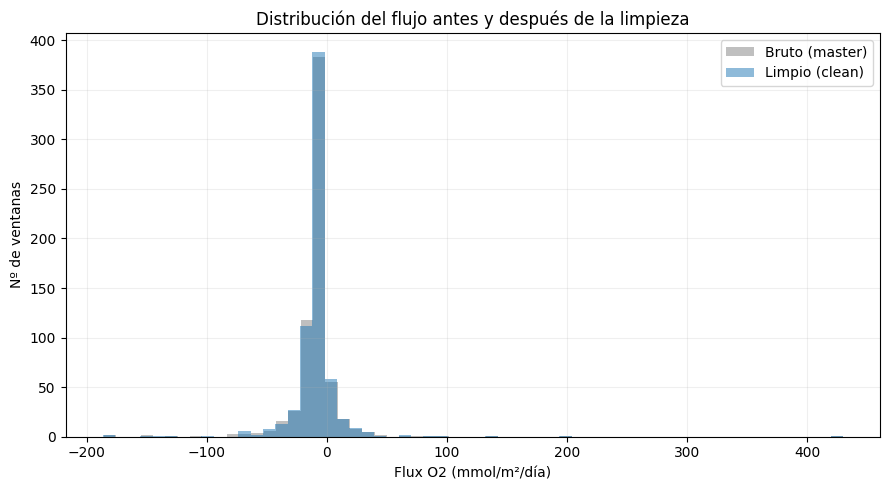

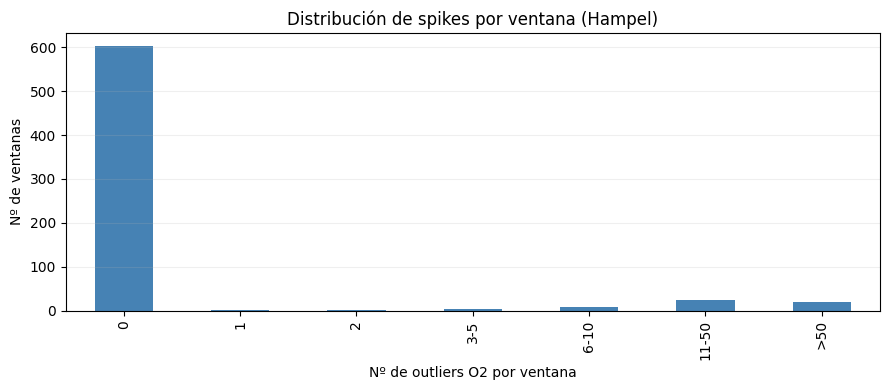

In [23]:
cmp = df_flux_clean_nb[["window_id", "hour", "flux_O2", "valid_flux_window"]].rename(
    columns={"flux_O2": "flux_clean", "valid_flux_window": "valid_clean"}
).merge(
    df_flux_master[["window_id", "flux_O2", "valid_flux_window"]].rename(
        columns={"flux_O2": "flux_master", "valid_flux_window": "valid_master"}
    ),
    on="window_id", how="inner"
).merge(
    qc[["window_id", "has_outliers", "n_outliers_O2", "n_interpolated_O2"]],
    on="window_id", how="left"
)

cmp["has_outliers"] = cmp["has_outliers"].fillna(False).astype(bool)
cmp["ganancia"] = cmp["valid_clean"] & ~cmp["valid_master"]  # ventanas ganadas
cmp["perdida"] = ~cmp["valid_clean"] & cmp["valid_master"]   # ventanas perdidas
cmp["flux_diff"] = cmp["flux_clean"] - cmp["flux_master"]


# ---- Figura 1: Distribución del flujo con/sin corrección ----
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(cmp["flux_master"].dropna(), bins=60, alpha=0.5, color="gray", label="Bruto (master)")
ax.hist(cmp["flux_clean"].dropna(),  bins=60, alpha=0.5, color="tab:blue", label="Limpio (clean)")
ax.set_xlabel("Flux O2 (mmol/m²/día)")
ax.set_ylabel("Nº de ventanas")
ax.set_title("Distribución del flujo antes y después de la limpieza")
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# ---- Figura 2: Outliers por ventana — distribución ----
if "n_outliers_O2" in cmp.columns:
    fig, ax = plt.subplots(figsize=(9, 4))
    bins = [0, 1, 2, 3, 5, 10, 50, cmp["n_outliers_O2"].max() + 1]
    labels = ["0", "1", "2", "3-5", "6-10", "11-50", ">50"]
    cmp["outlier_bin"] = pd.cut(cmp["n_outliers_O2"], bins=bins, labels=labels, right=False)
    cmp["outlier_bin"].value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue")
    ax.set_xlabel("Nº de outliers O2 por ventana")
    ax.set_ylabel("Nº de ventanas")
    ax.set_title("Distribución de spikes por ventana (Hampel)")
    ax.grid(True, alpha=0.2, axis="y")
    plt.tight_layout()
    plt.show()

PARA DISCUTIR: criterio experto sobre spikes
Ventanas con spike detectado:            322
De esas, con flujo resultante NORMAL:    267 (82.9%)
  (flujo dentro de [-25.04, 8.55] mmol/m²/día)

→ Estas ventanas son casos donde Hampel detectó el punto anómalo
  correctamente, pero la corrección no alteró el flujo de forma
  significativa. Esto valida la decisión de NO descartar la ventana
  solo por tener spikes: la señal físicamente es coherente.



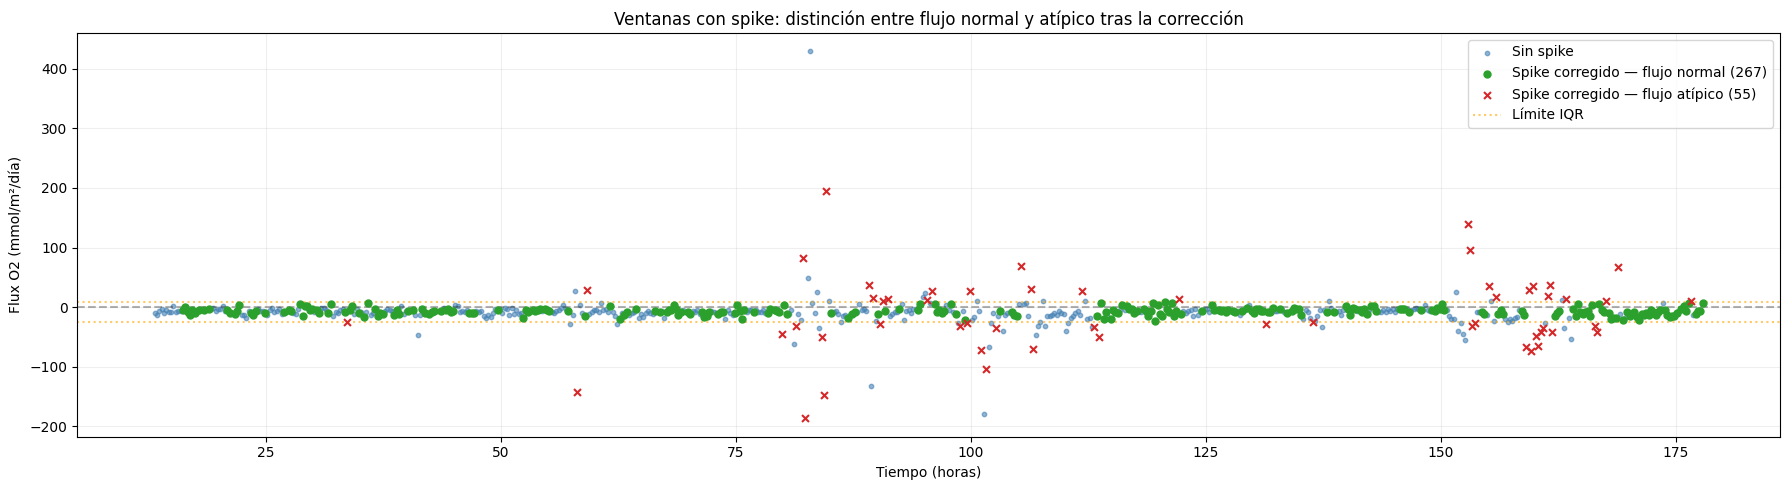

In [24]:
# ============================================================
# PARA DISCUTIR: outliers que Hampel marcó pero cuyo flujo
# resultante es normal
# ============================================================

# Definir "flujo normal" como dentro del rango IQR global
q25 = cmp["flux_clean"].quantile(0.25)
q75 = cmp["flux_clean"].quantile(0.75)
iqr_flux = q75 - q25
limite_bajo = q25 - 1.5 * iqr_flux
limite_alto = q75 + 1.5 * iqr_flux

# Ventanas con spike pero flujo dentro del rango esperado
mask_spike_flujo_normal = (
    cmp["has_outliers"] &
    cmp["flux_clean"].between(limite_bajo, limite_alto) &
    cmp["valid_clean"]
)

n_spike_flujo_normal = mask_spike_flujo_normal.sum()
n_spike_total = cmp["has_outliers"].sum()

print("=" * 55)
print("PARA DISCUTIR: criterio experto sobre spikes")
print("=" * 55)
print(f"Ventanas con spike detectado:            {n_spike_total}")
print(f"De esas, con flujo resultante NORMAL:    {n_spike_flujo_normal} ({100*n_spike_flujo_normal/n_spike_total:.1f}%)")
print(f"  (flujo dentro de [{limite_bajo:.2f}, {limite_alto:.2f}] mmol/m²/día)")
print()
print("→ Estas ventanas son casos donde Hampel detectó el punto anómalo")
print("  correctamente, pero la corrección no alteró el flujo de forma")
print("  significativa. Esto valida la decisión de NO descartar la ventana")
print("  solo por tener spikes: la señal físicamente es coherente.")
print()

# Visualización: flujo de ventanas spike-flujo-normal vs resto
fig, ax = plt.subplots(figsize=(18, 5))
normal_no_spike = cmp[~cmp["has_outliers"] & cmp["valid_clean"]]
spike_ok = cmp[mask_spike_flujo_normal]
spike_bad = cmp[cmp["has_outliers"] & ~mask_spike_flujo_normal & cmp["valid_clean"]]

ax.scatter(normal_no_spike["hour"], normal_no_spike["flux_clean"],
           color="steelblue", s=10, alpha=0.6, label="Sin spike")
ax.scatter(spike_ok["hour"], spike_ok["flux_clean"],
           color="tab:green", s=25, zorder=5, label=f"Spike corregido — flujo normal ({n_spike_flujo_normal})")
ax.scatter(spike_bad["hour"], spike_bad["flux_clean"],
           color="tab:red", s=25, zorder=5, marker="x",
           label=f"Spike corregido — flujo atípico ({len(spike_bad)})")
ax.axhline(0, linestyle="--", color="black", alpha=0.3)
ax.axhline(limite_alto, linestyle=":", color="orange", alpha=0.6, label="Límite IQR")
ax.axhline(limite_bajo, linestyle=":", color="orange", alpha=0.6)
ax.set_xlabel("Tiempo (horas)")
ax.set_ylabel("Flux O2 (mmol/m²/día)")
ax.set_title("Ventanas con spike: distinción entre flujo normal y atípico tras la corrección")
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()